In [77]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
#  Step 1: Data Collection & Loading

In [79]:
df = pd.read_csv("/content/synthetic_disaster_events_2025.csv")

In [80]:
df.shape

(20000, 13)

In [81]:
# Step 2: Initial Data Inspection

In [82]:
df.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [83]:
df.tail()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
19995,19996,Volcanic Eruption,India,19.962542,82.590546,2025-11-16,6,28135,2556182.54,38.71,No,0.69,0
19996,19997,Volcanic Eruption,Japan,35.853659,138.522874,2025-04-08,2,4340,1228534.00,7.67,No,0.18,0
19997,19998,Hurricane,Philippines,13.720136,121.306074,2025-08-26,8,44663,8518260.66,9.76,Yes,0.75,1
19998,19999,Volcanic Eruption,India,19.959071,77.272460,2023-03-24,7,37484,10802942.53,13.87,Yes,0.77,1
19999,20000,Landslide,Chile,-36.842195,-68.613505,2023-04-05,6,34441,8966848.02,4.01,Yes,0.60,0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

In [85]:
df.describe()

,event_id,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,infrastructure_damage_index,is_major_disaster
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000
mean,10000.500000,18.749811,41.976629,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005
std,5773.647028,25.026759,82.535922,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992
min,1.000000,-43.127383,-102.133704,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000
25%,5000.750000,3.560059,8.346726,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000
50%,10000.500000,24.361006,74.600322,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000
75%,15000.250000,38.285895,117.460836,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000
max,20000.000000,48.452161,145.902669,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000


In [86]:
df.columns

Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
       'date', 'severity_level', 'affected_population',
       'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
       'infrastructure_damage_index', 'is_major_disaster'],
      dtype='object')

In [87]:
df['is_major_disaster'].value_counts()

,count
is_major_disaster,
0,11999
1,8001


In [88]:
#  Step 3: Data Cleaning

In [89]:
df.isnull().sum()

,0
event_id,0
disaster_type,0
location,0
latitude,0
longitude,0
date,0
severity_level,0
affected_population,0
estimated_economic_loss_usd,0
response_time_hours,0


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
# Step 4: Exploratory Data Analysis (EDA)

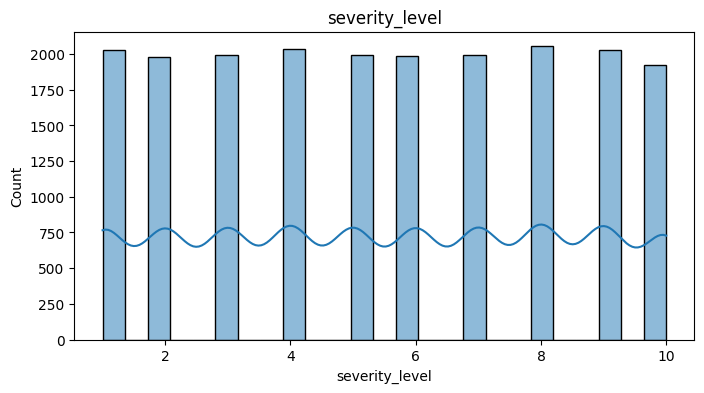

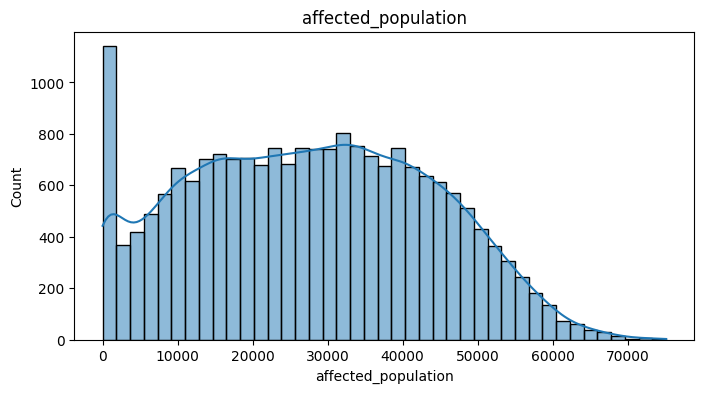

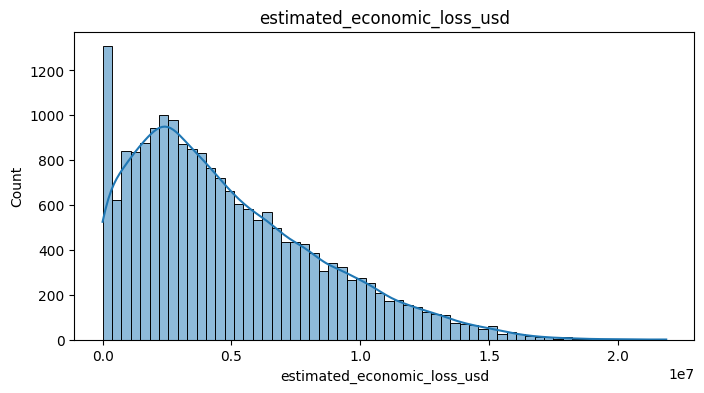

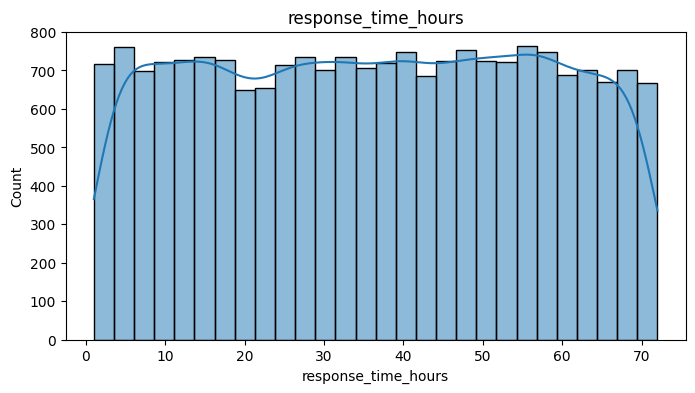

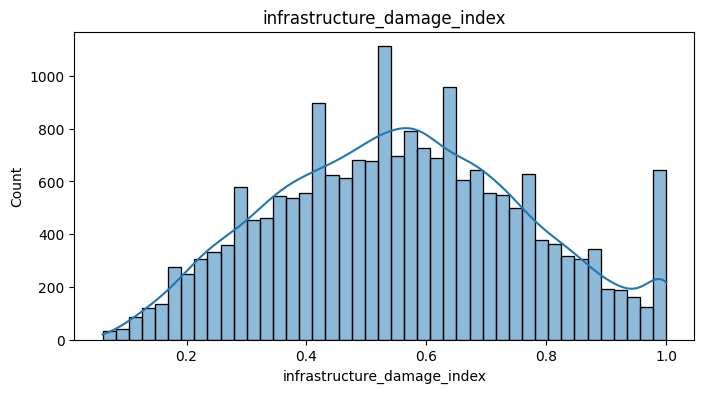

In [92]:
num_cols = ["severity_level", "affected_population", "estimated_economic_loss_usd", "response_time_hours", "infrastructure_damage_index"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [93]:
df[num_cols].skew()

,0
severity_level,-0.003133
affected_population,0.087780
estimated_economic_loss_usd,0.874637
response_time_hours,-0.009637
infrastructure_damage_index,0.100800


In [94]:
df['estimated_economic_loss_usd'] = np.log1p(df['estimated_economic_loss_usd'])

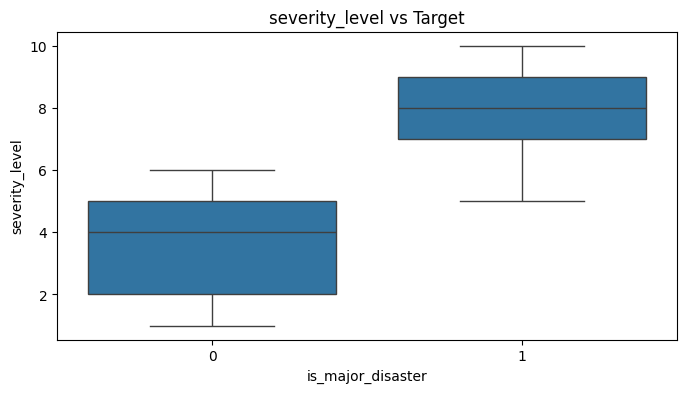

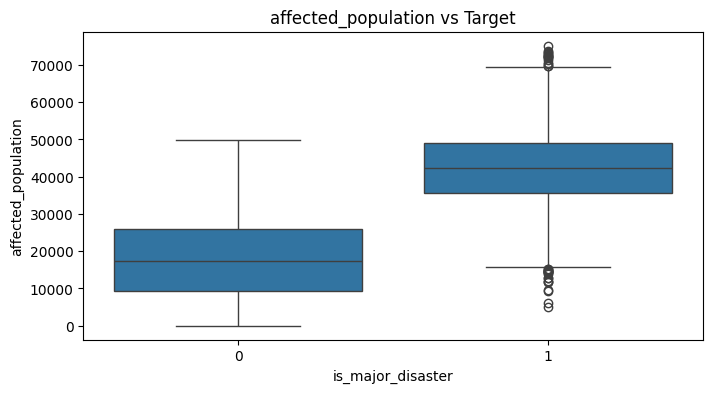

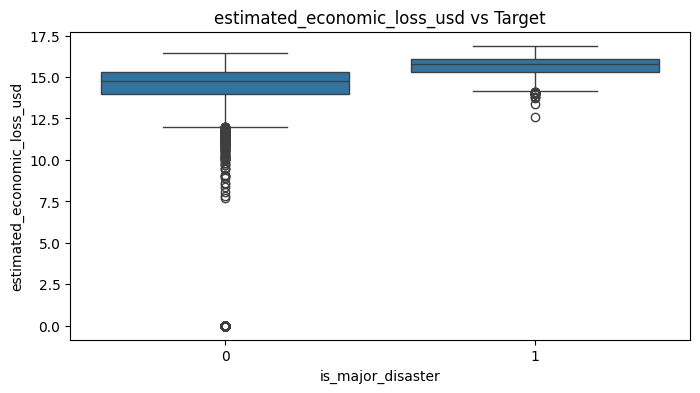

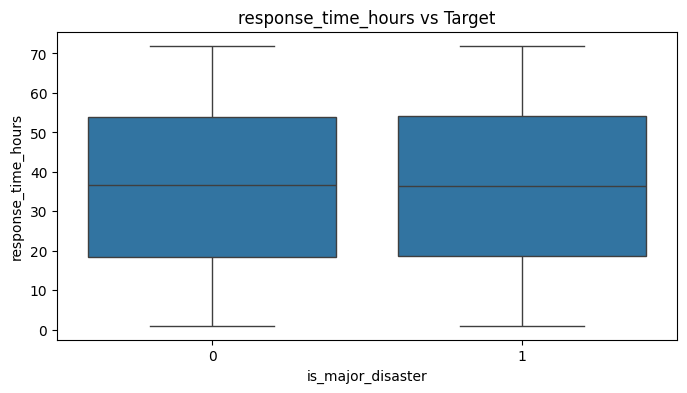

In [95]:
features = ['severity_level','affected_population',
            'estimated_economic_loss_usd',
            'response_time_hours']

for col in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='is_major_disaster', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

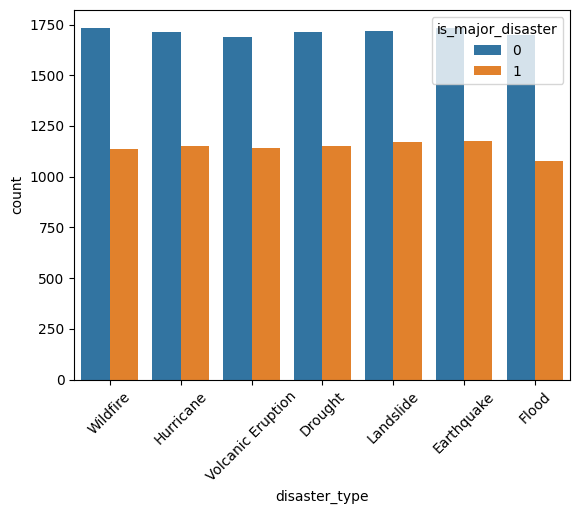

In [96]:
sns.countplot(x='disaster_type', hue='is_major_disaster', data=df)
plt.xticks(rotation=45)
plt.show()

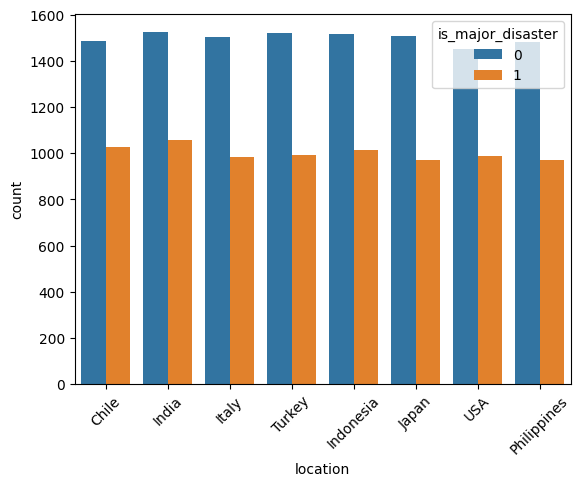

In [97]:
sns.countplot(x='location', hue='is_major_disaster', data=df)
plt.xticks(rotation=45)
plt.show()

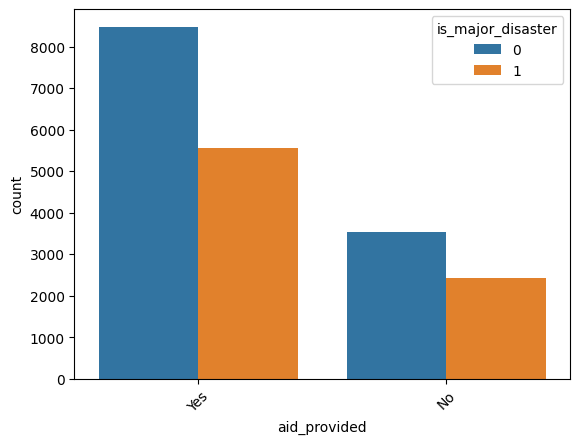

In [98]:
sns.countplot(x='aid_provided', hue='is_major_disaster', data=df)
plt.xticks(rotation=45)
plt.show()

In [99]:
df.select_dtypes(include=['number']).corr()['is_major_disaster']

,is_major_disaster
event_id,-0.016152
latitude,-0.007837
longitude,-0.007275
severity_level,0.852570
affected_population,0.751958
estimated_economic_loss_usd,0.313188
response_time_hours,-0.003152
infrastructure_damage_index,0.574027
is_major_disaster,1.000000


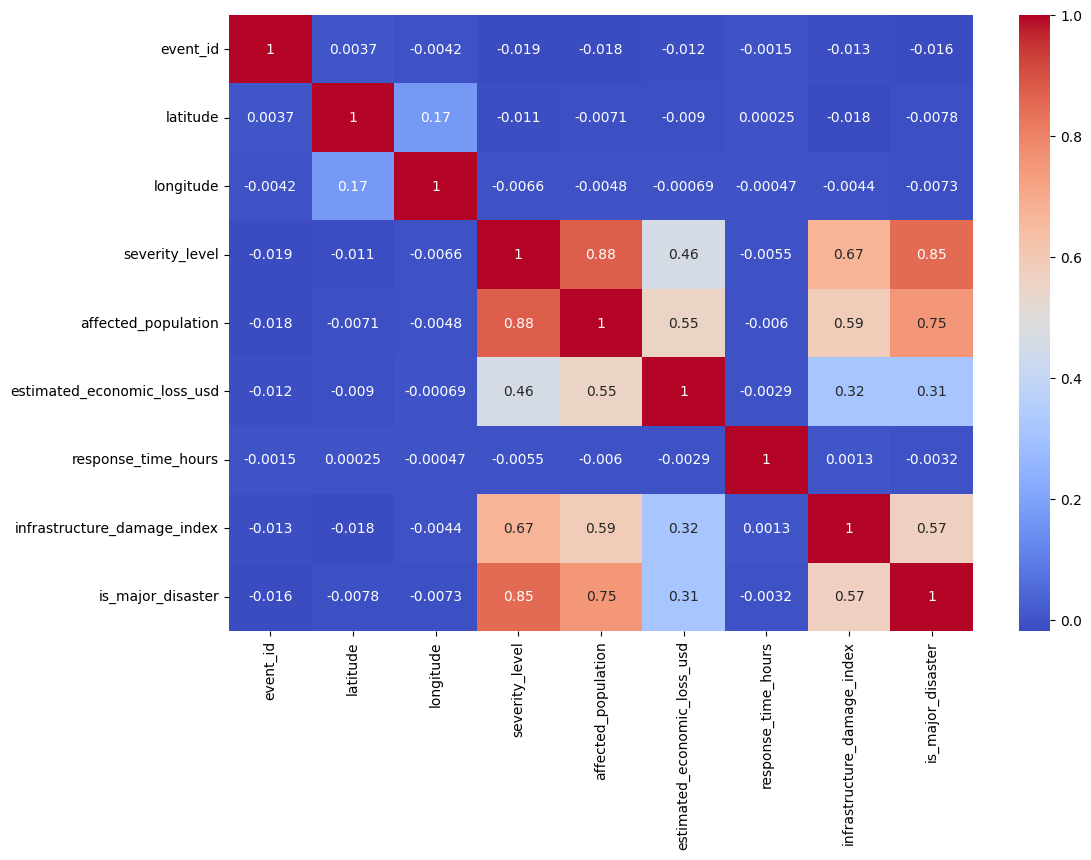

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

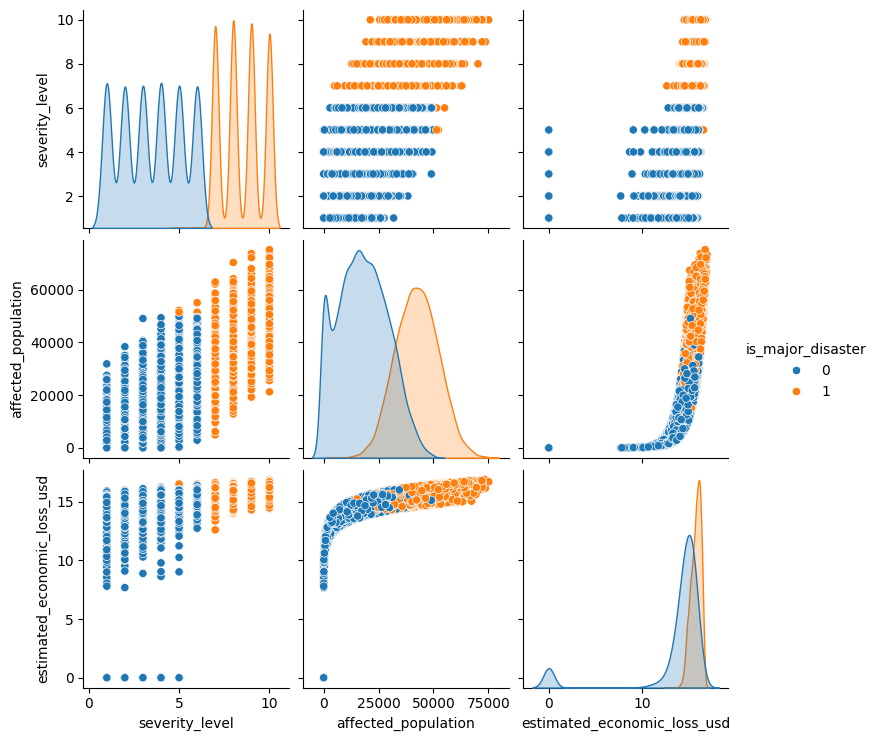

In [101]:
sns.pairplot(df[['severity_level',
                 'affected_population',
                 'estimated_economic_loss_usd',
                 'is_major_disaster']],
             hue='is_major_disaster')
plt.show()

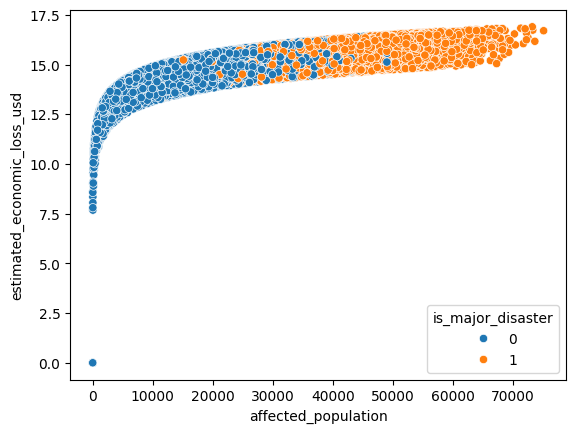

In [102]:
sns.scatterplot(
    x='affected_population',
    y='estimated_economic_loss_usd',
    hue='is_major_disaster',
    data=df
)
plt.show()

In [103]:
# Step 5: Outlier Detection & Treatment

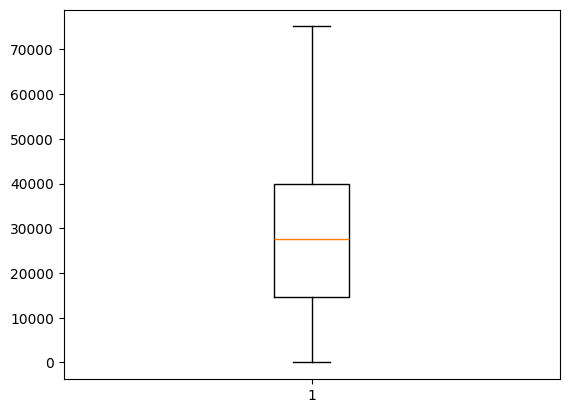

In [104]:
plt.boxplot(df['affected_population'])
plt.show()

In [105]:
Q1 = df['response_time_hours'].quantile(0.25)
Q3 = df['response_time_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['response_time_hours'] < lower) |
              (df['response_time_hours'] > upper)]

print(outliers)

Empty DataFrame
Columns: [event_id, disaster_type, location, latitude, longitude, date, severity_level, affected_population, estimated_economic_loss_usd, response_time_hours, aid_provided, infrastructure_damage_index, is_major_disaster]
Index: []


In [106]:
# Step 6: Feature Encoding

In [107]:
df.drop(columns=['event_id'], inplace=True)

In [108]:
df['date'] = pd.to_datetime(df['date'])

In [109]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [110]:
df.drop(columns=['date'], inplace=True)

In [111]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['disaster_type', 'location', 'aid_provided']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [112]:
df.head()

,disaster_type,location,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster,year,month,day
0,6,0,-34.681672,-71.819529,8,31104,14.833713,5.12,1,0.59,1,2025,8,27
1,3,1,22.128569,78.023951,5,29340,15.606641,44.43,0,0.26,0,2023,5,29
2,5,3,42.316058,11.031447,7,34804,16.037161,49.30,0,0.94,1,2023,1,15
3,0,0,-33.436253,-69.984615,8,31191,14.418571,65.56,1,0.94,1,2024,2,8
4,5,6,39.400977,37.006822,8,46284,16.413442,60.96,0,0.92,1,2023,12,23


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   disaster_type                20000 non-null  int64  
 1   location                     20000 non-null  int64  
 2   latitude                     20000 non-null  float64
 3   longitude                    20000 non-null  float64
 4   severity_level               20000 non-null  int64  
 5   affected_population          20000 non-null  int64  
 6   estimated_economic_loss_usd  20000 non-null  float64
 7   response_time_hours          20000 non-null  float64
 8   aid_provided                 20000 non-null  int64  
 9   infrastructure_damage_index  20000 non-null  float64
 10  is_major_disaster            20000 non-null  int64  
 11  year                         20000 non-null  int32  
 12  month                        20000 non-null  int32  
 13  day             

In [114]:
# Step 7: Feature Scaling & Step 8: Train-Test Split

In [115]:
from sklearn.model_selection import train_test_split

X = df.drop('is_major_disaster', axis=1)
y = df['is_major_disaster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)